In [6]:
!pip install pandas matplotlib seaborn

In [7]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('train.csv')

# First look at the data
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
#Check shape_how many rows and columns
print("shape:", df.shape)
# Check column names
print("\nColumns:", df.columns.tolist())

# Check data types and missing values
print("\nInfo:")
df.info()

shape: (891, 12)

Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [9]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [10]:

                 # Fill missing Age with median age
df['Age'].fillna(df['Age'].median(), inplace=True)

# Fill missing Embarked with most common value
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Drop Cabin column - too many missing values
df.drop(columns=['Cabin'], inplace=True)

# Confirm no more missing values
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


C:\Users\evija\AppData\Local\Temp\ipykernel_29972\1253080607.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
C:\Users\evija\AppData\Local\Temp\ipykernel_29972\1253080607.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For e

Survival Count:
Survived
0    549
1    342
Name: count, dtype: int64

Survival Rate: 38.38%


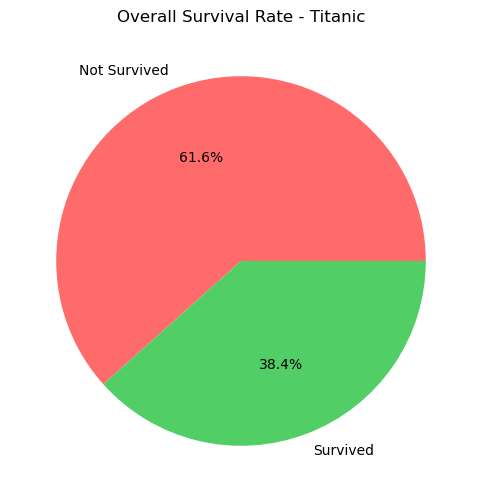

In [12]:
# Overall survival rate
survival_rate = df['Survived'].value_counts()
print("Survival Count:")
print(survival_rate)
print(f"\nSurvival Rate: {df['Survived'].mean()*100:.2f}%")

# Plot pie chart
plt.figure(figsize=(6,6))
plt.pie(survival_rate, labels=['Not Survived', 'Survived'], 
        autopct='%1.1f%%', colors=['#ff6b6b', '#51cf66'])
plt.title('Overall Survival Rate - Titanic')
plt.show()


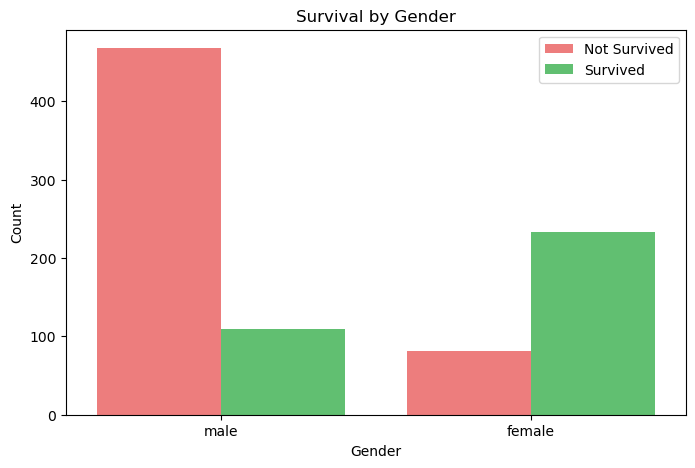

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


In [13]:
# Survival by Gender
plt.figure(figsize=(8,5))
sns.countplot(x='Sex', hue='Survived', data=df, 
              palette=['#ff6b6b', '#51cf66'])
plt.title('Survival by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(['Not Survived', 'Survived'])
plt.show()

# Print numbers
print(df.groupby('Sex')['Survived'].mean()*100)

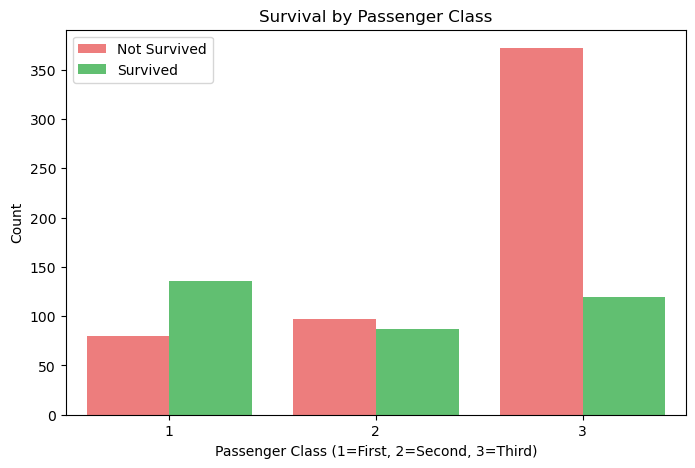

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


In [14]:
# Survival by Class
plt.figure(figsize=(8,5))
sns.countplot(x='Pclass', hue='Survived', data=df,
              palette=['#ff6b6b', '#51cf66'])
plt.title('Survival by Passenger Class')
plt.xlabel('Passenger Class (1=First, 2=Second, 3=Third)')
plt.ylabel('Count')
plt.legend(['Not Survived', 'Survived'])
plt.show()

# Print percentages
print(df.groupby('Pclass')['Survived'].mean()*100)


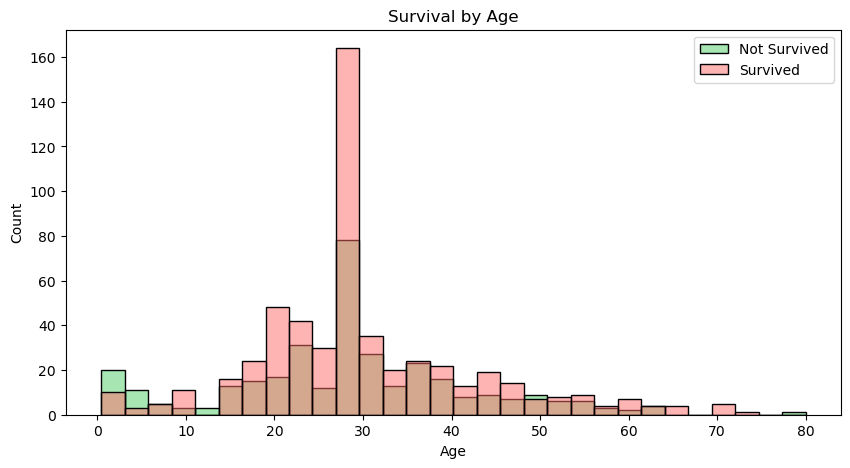

In [15]:
# Survival by Age
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='Age', hue='Survived', 
             bins=30, palette=['#ff6b6b', '#51cf66'])
plt.title('Survival by Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(['Not Survived', 'Survived'])
plt.show()

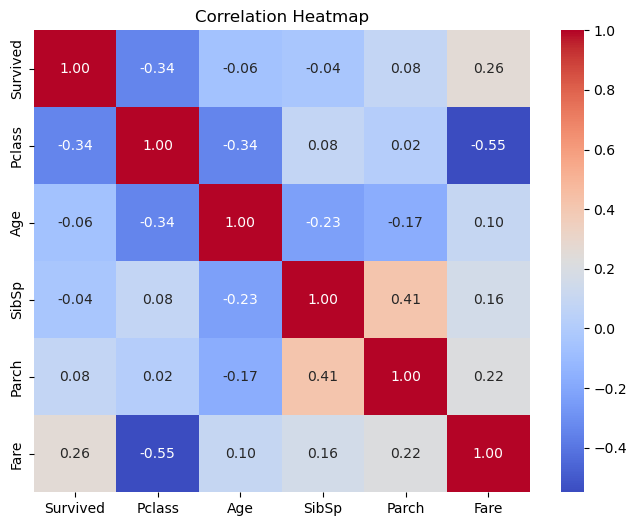

In [16]:
# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].corr(), 
            annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()